# ACDC Preprocessed 2D Preprocessing

This notebook prepares the local `ACDC_preprocessed` HDF5 dataset for 2D segmentation experiments.

The notebook keeps the implementation intentionally simple:

1. Choose one 2D target size.
2. List the HDF5 files.
3. Load `image` and `label` arrays.
4. Center crop or zero-pad each 2D slice.
5. Normalize the image to zero mean and unit variance.
6. Optionally save processed files.

The notebook ignores `scribble` annotations and uses the full `label` masks for supervised segmentation.

**What this cell does:** Imports the needed libraries and sets the dataset/output paths.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Make paths work whether the notebook is opened from the project root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "ACDC_preprocessed"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "acdc_preprocessed_2d"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_ROOT}")

DATA_ROOT

PosixPath('/home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge/ACDC_preprocessed')

## Choose Target Size

Use `224 x 224` for FCN-8 or `396 x 396` for 2D U-Net. Change the values in the next cell when needed.

**What this cell does:** Sets the active 2D model name and target slice size.

In [2]:
# Pick one setup by editing these two variables.
MODEL_NAME = "2D U-Net"
TARGET_HEIGHT = 224
TARGET_WIDTH = 224

print(f"Model: {MODEL_NAME}")
print(f"Target slice size: {TARGET_HEIGHT} x {TARGET_WIDTH}")

Model: 2D U-Net
Target slice size: 224 x 224


## List Dataset Files

The dataset is already in HDF5 format. This section builds a simple table of the available files.

**What this cell does:** Builds a simple manifest table with split, file path, patient number, frame number, and optional slice number.

In [3]:
def parse_file_name(file_path):
    # Handles names like:
    # patient001_frame01.h5
    # patient001_frame01_slice_0.h5
    name = file_path.stem

    # Remove copy suffixes like patient001_frame01_slice_2(1).h5.
    if name.endswith(")") and "(" in name:
        base, suffix = name.rsplit("(", 1)
        if suffix[:-1].isdigit():
            name = base

    parts = name.split("_")
    patient = int(parts[0].replace("patient", ""))
    frame = int(parts[1].replace("frame", ""))

    slice_number = None
    if len(parts) == 4:
        slice_number = int(parts[3])

    return patient, frame, slice_number


rows = []
for file_path in sorted(DATA_ROOT.glob("*/*.h5")):
    patient, frame, slice_number = parse_file_name(file_path)
    kind = "slice" if slice_number is not None else "volume"
    rows.append({
        "split": file_path.parent.name,
        "kind": kind,
        "patient": patient,
        "frame": frame,
        "slice": slice_number,
        "file": file_path.name,
        "path": file_path,
        "size_kb": file_path.stat().st_size / 1024,
    })

manifest = pd.DataFrame(rows)
print(f"Found {len(manifest):,} HDF5 files")
manifest.head()

Found 2,212 HDF5 files


,split,kind,patient,frame,slice,file,path,size_kb
0,ACDC_testing_volumes,volume,101,1,NaN,patient101_frame01.h5,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,637.666016
1,ACDC_testing_volumes,volume,101,14,NaN,patient101_frame14.h5,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,593.673828
2,ACDC_testing_volumes,volume,102,1,NaN,patient102_frame01.h5,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,463.086914
3,ACDC_testing_volumes,volume,102,13,NaN,patient102_frame13.h5,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,458.013672
4,ACDC_testing_volumes,volume,103,1,NaN,patient103_frame01.h5,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,518.853516


**What this cell does:** Shows a compact summary of how many files and patients are in each split.

In [4]:
summary = manifest.groupby(["split", "kind"]).agg(
    files=("file", "count"),
    patients=("patient", "nunique"),
    frames=("frame", "nunique"),
    size_mb=("size_kb", lambda values: values.sum() / 1024),
)

summary.reset_index()

,split,kind,files,patients,frames,size_mb
0,ACDC_testing_volumes,volume,100,50,11,53.297203
1,ACDC_training_slices,slice,1912,100,13,139.172810
2,ACDC_training_volumes,volume,200,100,13,117.114828


## Preprocessing Helpers

These helpers are small and direct: one loads HDF5 data, one resizes a 2D slice, and one normalizes image intensities.

**What this cell does:** Defines a simple HDF5 loader that reads `image` and `label`, while ignoring `scribble`.

In [5]:
def load_h5(file_path):
    with h5py.File(file_path, "r") as h5_file:
        image = h5_file["image"][:]
        label = h5_file["label"][:] if "label" in h5_file else None
    return image, label

**What this cell does:** Defines a simple center crop / zero-pad function for one 2D slice.

In [6]:
def resize_slice_2d(slice_2d, target_height, target_width, pad_value=0):
    result = slice_2d

    # Crop height if needed.
    if result.shape[0] > target_height:
        start = (result.shape[0] - target_height) // 2
        result = result[start:start + target_height, :]

    # Crop width if needed.
    if result.shape[1] > target_width:
        start = (result.shape[1] - target_width) // 2
        result = result[:, start:start + target_width]

    # Pad height if needed.
    pad_top = max((target_height - result.shape[0]) // 2, 0)
    pad_bottom = max(target_height - result.shape[0] - pad_top, 0)

    # Pad width if needed.
    pad_left = max((target_width - result.shape[1]) // 2, 0)
    pad_right = max(target_width - result.shape[1] - pad_left, 0)

    if pad_top or pad_bottom or pad_left or pad_right:
        result = np.pad(
            result,
            ((pad_top, pad_bottom), (pad_left, pad_right)),
            mode="constant",
            constant_values=pad_value,
        )

    return result

**What this cell does:** Defines image normalization and a simple function that preprocesses either a slice file or a volume file as independent 2D slices.

In [7]:
def normalize_image(image):
    image = image.astype(np.float32)
    mean = image.mean()
    std = image.std()

    if std == 0:
        normalized = image - mean
    else:
        normalized = (image - mean) / std

    stats = {"mean": float(mean), "std": float(std)}
    return normalized.astype(np.float32), stats


def preprocess_file_2d(file_path):
    image, label = load_h5(file_path)

    # If this is one slice, add a temporary slice axis so the loop is the same for both cases.
    input_was_single_slice = image.ndim == 2
    if input_was_single_slice:
        image = image[None, :, :]
        if label is not None:
            label = label[None, :, :]

    processed_images = []
    processed_labels = []

    for slice_index in range(image.shape[0]):
        image_slice = resize_slice_2d(image[slice_index], TARGET_HEIGHT, TARGET_WIDTH, pad_value=0)
        processed_images.append(image_slice)

        if label is not None:
            label_slice = resize_slice_2d(label[slice_index], TARGET_HEIGHT, TARGET_WIDTH, pad_value=0)
            processed_labels.append(label_slice.astype(np.uint8))

    processed_image = np.stack(processed_images)
    processed_image, normalization_stats = normalize_image(processed_image)

    processed_label = None
    if label is not None:
        processed_label = np.stack(processed_labels)

    # Return a 2D array again if the input was a single 2D slice file.
    if input_was_single_slice:
        processed_image = processed_image[0]
        if processed_label is not None:
            processed_label = processed_label[0]

    return processed_image, processed_label, normalization_stats

## Example Preprocessing

Run the preprocessing on one training volume and inspect the shape and intensity statistics.

**What this cell does:** Preprocesses one example training volume and compares the input/output shapes and image statistics.

In [8]:
example_path = manifest[manifest["split"] == "ACDC_training_volumes"].iloc[0]["path"]

input_image, input_label = load_h5(example_path)
processed_image, processed_label, stats = preprocess_file_2d(example_path)

example_summary = pd.DataFrame([
    {
        "stage": "input",
        "image_shape": input_image.shape,
        "label_shape": input_label.shape if input_label is not None else None,
        "image_mean": input_image.mean(),
        "image_std": input_image.std(),
        "image_min": input_image.min(),
        "image_max": input_image.max(),
    },
    {
        "stage": "processed",
        "image_shape": processed_image.shape,
        "label_shape": processed_label.shape if processed_label is not None else None,
        "image_mean": processed_image.mean(),
        "image_std": processed_image.std(),
        "image_min": processed_image.min(),
        "image_max": processed_image.max(),
    },
])

print(example_path.relative_to(PROJECT_ROOT))
example_summary

ACDC_preprocessed/ACDC_training_volumes/patient001_frame01.h5


,stage,image_shape,label_shape,image_mean,image_std,image_min,image_max
0,input,"(10, 256, 216)","(10, 256, 216)",2.261416e-01,0.254622,0.000000,1.000000
1,processed,"(10, 224, 224)","(10, 224, 224)",6.325391e-09,1.000000,-0.908011,2.932656


**What this cell does:** Displays the middle slice before and after preprocessing.

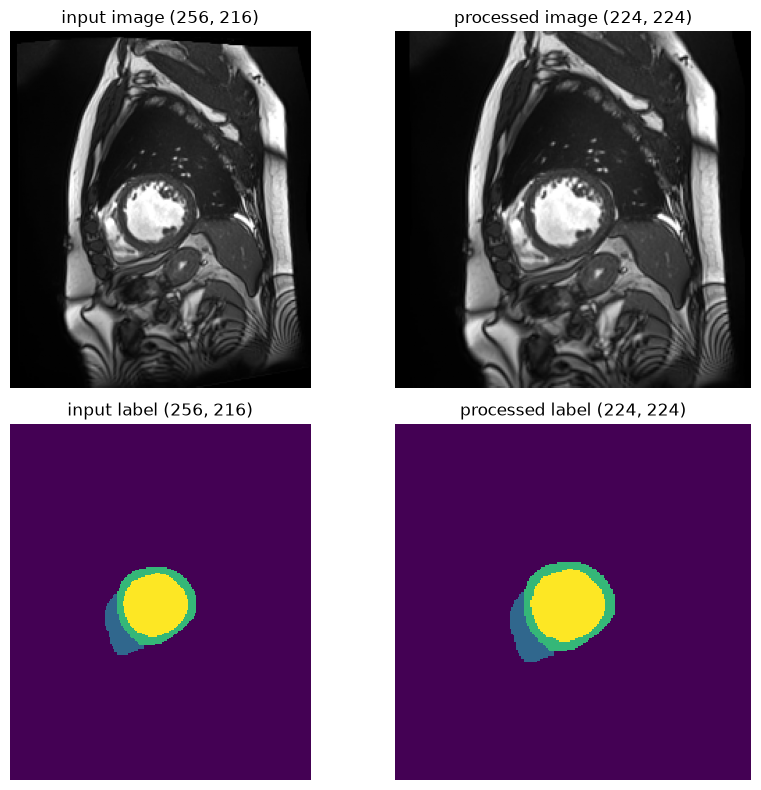

In [9]:
def get_middle_slice(array):
    if array.ndim == 2:
        return array
    middle = array.shape[0] // 2
    return array[middle]


input_image_slice = get_middle_slice(input_image)
processed_image_slice = get_middle_slice(processed_image)
input_label_slice = get_middle_slice(input_label) if input_label is not None else None
processed_label_slice = get_middle_slice(processed_label) if processed_label is not None else None

fig, axes = plt.subplots(2, 2, figsize=(9, 8))

axes[0, 0].imshow(input_image_slice, cmap="gray")
axes[0, 0].set_title(f"input image {input_image_slice.shape}")

axes[0, 1].imshow(processed_image_slice, cmap="gray")
axes[0, 1].set_title(f"processed image {processed_image_slice.shape}")

axes[1, 0].imshow(input_label_slice, interpolation="nearest")
axes[1, 0].set_title(f"input label {input_label_slice.shape}")

axes[1, 1].imshow(processed_label_slice, interpolation="nearest")
axes[1, 1].set_title(f"processed label {processed_label_slice.shape}")

for axis in axes.ravel():
    axis.axis("off")

plt.tight_layout()

## Optional Batch Export

The next cell can write a processed copy of the dataset. It is off by default so the notebook does not create many files accidentally.

**What this cell does:** Defines a simple save function and an optional loop that writes processed HDF5 files.

In [10]:
def save_processed_file(output_path, image, label, stats, source_path):
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with h5py.File(output_path, "w") as h5_file:
        h5_file.create_dataset("image", data=image, compression="gzip")
        if label is not None:
            h5_file.create_dataset("label", data=label, compression="gzip")

        h5_file.attrs["source_path"] = str(source_path.relative_to(PROJECT_ROOT))
        h5_file.attrs["model_name"] = MODEL_NAME
        h5_file.attrs["target_height"] = TARGET_HEIGHT
        h5_file.attrs["target_width"] = TARGET_WIDTH
        h5_file.attrs["normalization_mean"] = stats["mean"]
        h5_file.attrs["normalization_std"] = stats["std"]


RUN_BATCH_EXPORT = True

if RUN_BATCH_EXPORT:
    export_rows = []

    for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
        source_path = row["path"]
        image, label, stats = preprocess_file_2d(source_path)

        output_path = OUTPUT_ROOT / row["split"] / row["file"]
        save_processed_file(output_path, image, label, stats, source_path)

        export_rows.append({
            "source": source_path,
            "output": output_path,
            "image_shape": image.shape,
            "has_label": label is not None,
        })

    export_summary = pd.DataFrame(export_rows)
else:
    print("Batch export is disabled. Set RUN_BATCH_EXPORT = True to write processed files.")
    export_summary = pd.DataFrame()

export_summary.head()

  0%|          | 0/2212 [00:00<?, ?it/s]

,source,output,image_shape,has_label
0,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,"(10, 224, 224)",True
1,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,"(10, 224, 224)",True
2,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,"(8, 224, 224)",True
3,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,"(8, 224, 224)",True
4,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,"(9, 224, 224)",True


## Notes

- This notebook uses only `ACDC_preprocessed`.
- It preprocesses data as 2D slices.
- It ignores `scribble` keys and uses full `label` masks.
- It does not do physical spacing resampling because these HDF5 files do not contain voxel spacing metadata.